In [1]:
# Copyright (c) TorchGeo Contributors. All rights reserved.
# Licensed under the MIT License.

# Aurora + ERA5 (WeatherBench 2)

This tutorial runs Microsoft's [Aurora](https://github.com/microsoft/aurora) foundation model on [WeatherBench 2](https://weatherbench2.readthedocs.io/) ERA5 data, then compares the forecast against ERA5 truth over the continental U.S. It's recommended to run this on a machine with a GPU and at least ~16 GB of GPU RAM.

## Setup

In [2]:
import os
import tempfile

import matplotlib.pyplot as plt
import pandas as pd
import torch
from aurora import rollout

from torchgeo.datamodules import (
    WeatherBench2AuroraDataModule,
    aurora_predictions_to_xarray,
)
from torchgeo.datasets import WeatherBench2
from torchgeo.models import Aurora_Weights, aurora_swin_unet

## Load the pretrained Aurora model

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = (
    aurora_swin_unet(weights=Aurora_Weights.HRES_T0_PRETRAINED_AURORA).to(device).eval()
)

## Load WeatherBench2

`WeatherBench2()` by default streams the public 0.25° ERA5 store from `gs://weatherbench2/datasets/era5/` (anonymous access is set automatically for `gs://` URIs); it can also load from a local store. Use `dataset.data` for arbitrary `xarray.Dataset.sel(...)` slicing and `dataset.plot(variable, time, ...)` for quick visualization. We can use a `dataset.plot(variable, time, ...)` call to check one of the input fields. Pass `region=(xmin, ymin, xmax, ymax)` to select using a bounding box.

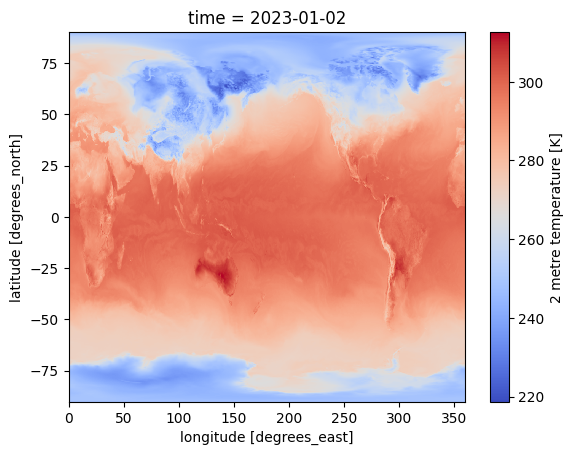

In [8]:
wb2 = WeatherBench2()
init_time = pd.Timestamp('2023-01-02 00:00')
wb2.plot('2m_temperature', time=init_time, cmap='coolwarm')
plt.show()

## Build an Aurora batch and roll out

`WeatherBench2AuroraDataModule` stacks `context_steps + target_steps = 3` 6 h windows along the time axis and produces an `aurora.Batch`. By default it uses the dataset's full spatial bounds. With `context_steps=2`, Aurora sees `T-6h` and `T0` as history.

`aurora.rollout` is a generator: each iteration runs one forward pass and shifts its prediction into the history window for the next step. We move predictions to CPU so that comparing lead times doesn't keep `steps × model_state` memory on the GPU.

In [5]:
steps = 4

infer_dm = WeatherBench2AuroraDataModule(
    paths=wb2.paths,
    start_time=init_time - pd.Timedelta('6h'),
    end_time=init_time + pd.Timedelta('6h'),
)
infer_dm.setup('predict')
batch = next(iter(infer_dm.predict_dataloader()))['context'].to(device)

with torch.inference_mode():
    preds = [p.to('cpu') for p in rollout(model, batch, steps=steps)]

/projects/illinois/eng/cs/arindamb/cnagda2/torchgeo/torchgeo/torchgeo/datamodules/weatherbench.py:45: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  return torch.as_tensor(np.asarray(arr.values, dtype=np.float32))


## Save the forecast

`aurora_predictions_to_xarray` packs the rollout into a WeatherBench-shaped `xarray.Dataset` (WB2 variable names, `(time, latitude, longitude[, level])` coordinates) which we persist as a Zarr directory. Re-opening it through the `WeatherBench2` class gives us utility functions.

In [6]:
forecast_zarr = os.path.join(tempfile.mkdtemp(), 'forecast.zarr')
aurora_predictions_to_xarray(preds, init_time).to_zarr(forecast_zarr)
forecast_wb2 = WeatherBench2(paths=forecast_zarr)

/u/cnagda2/.local/lib/python3.12/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


## Compare to ERA5 over a region

Below we plot, for the continental U.S. (CONUS), defined by the region: `lon ∈ [235°, 285°]`, `lat ∈ [25°, 50°]`:

* Aurora's 2 m temperature at the longest lead time,
* the matching ERA5 truth at the same timestamp,
* the residual (Aurora − ERA5), and
* the regional MAE as a function of forecast horizon.

Plots use `dataset.plot(variable, time, region=...)` utility; the residual is just an xarray subtraction.

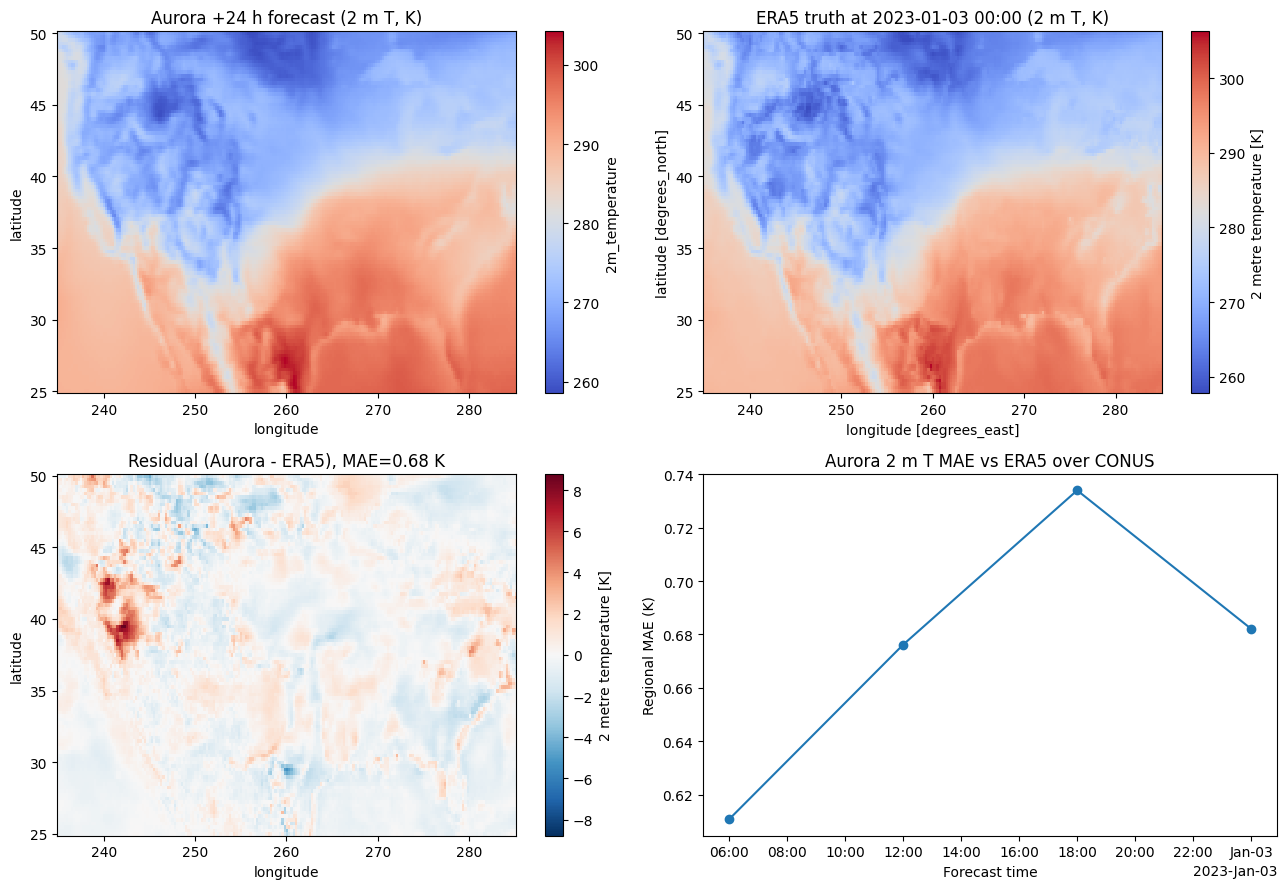

In [7]:
us_region = (235.0, 25.0, 285.0, 50.0)
last_time = pd.Timestamp(forecast_wb2.data.time.values[-1])

residual = (forecast_wb2.data['2m_temperature'] - wb2.data['2m_temperature']).sel(
    time=forecast_wb2.data.time,
    longitude=slice(us_region[0], us_region[2]),
    latitude=slice(us_region[3], us_region[1]),
)
mae_by_lead = abs(residual).mean(dim=('latitude', 'longitude'))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
forecast_wb2.plot(
    '2m_temperature', time=last_time, region=us_region, ax=axes[0, 0], cmap='coolwarm'
)
axes[0, 0].set_title(f'Aurora +{steps * 6} h forecast (2 m T, K)')
wb2.plot(
    '2m_temperature', time=last_time, region=us_region, ax=axes[0, 1], cmap='coolwarm'
)
axes[0, 1].set_title(f'ERA5 truth at {last_time:%Y-%m-%d %H:%M} (2 m T, K)')
residual.sel(time=last_time).plot.imshow(ax=axes[1, 0], cmap='RdBu_r')
axes[1, 0].set_title(f'Residual (Aurora - ERA5), MAE={float(mae_by_lead[-1]):.2f} K')
mae_by_lead.plot(ax=axes[1, 1], marker='o')
axes[1, 1].set_xlabel('Forecast time')
axes[1, 1].set_ylabel('Regional MAE (K)')
axes[1, 1].set_title('Aurora 2 m T MAE vs ERA5 over CONUS')
plt.tight_layout()
plt.show()

## To Go Further
* **Fine-tune Aurora**: on a region or variable set using its [dedicated fine-tuning procedure](https://microsoft.github.io/aurora/finetuning.html); however, fine-tuning risks degrading the pretrained representations and requires high-quality data. The datamodule's `train_dataloader` already supplies the context and target windows such a procedure needs.
* **Longer rollouts**:  extend the forecast horizon by increasing `steps` in the `rollout` call. Errors compound with lead time.
* **Forecasts as covariates**: use forecast temperature, wind, or humidity as inputs to downstream pipelines such as air pollution monitoring, crop type mapping, or change detection.
* **Benchmark Aurora**: for example against the [high-resolution forecasts that WeatherBench 2 also hosts](https://weatherbench2.readthedocs.io/en/latest/data-guide.html), or against other weather forecasting models.